In [1]:
from sympy.matrices import Matrix, zeros, eye, ones, diag
import numpy.linalg as npl
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
%matplotlib inline

### Создание матриц

In [2]:
m1 = Matrix([[1, 0, 0], [0, 1, 0]])
m1

Matrix([
[1, 0, 0],
[0, 1, 0]])

In [3]:
m2 = Matrix([1, 2, 3])  # вектор столбец
m2

Matrix([
[1],
[2],
[3]])

In [4]:
m3 = Matrix([[4, 5, 6]]) # вектор строка
m3

Matrix([[4, 5, 6]])

In [5]:
m4 = Matrix([m3, (7, 8, 9)])
m4

Matrix([
[4, 5, 6],
[7, 8, 9]])

In [6]:
m2.shape  # размерность - количество элементов в каждом измерении

(3, 1)

In [7]:
m3.shape

(1, 3)

In [8]:
# .T - это операция транспонирования
m5 = Matrix([m2.T, (7, 8, 9)])
m5

Matrix([
[1, 2, 3],
[7, 8, 9]])

In [9]:
m5.shape

(2, 3)

In [10]:
m6 = Matrix([[4, 7], [5, 8], [6, 9]])
m6

Matrix([
[4, 7],
[5, 8],
[6, 9]])

In [11]:
m7 = Matrix([m2.T, (20, 21, 22)]).T
m7

Matrix([
[1, 20],
[2, 21],
[3, 22]])

In [12]:
m7.shape

(3, 2)

In [13]:
m6 == m7

False

In [14]:
m5 == m5

True

In [15]:
m4 == m6

False

In [16]:
m4

Matrix([
[4, 5, 6],
[7, 8, 9]])

In [17]:
m6

Matrix([
[4, 7],
[5, 8],
[6, 9]])

In [18]:
m4 == m6.T

True

In [19]:
arr = np.array(range(10))
arr.shape

(10,)

In [20]:
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [21]:
np.matrix([56, 11]) # неявное преобразование к двумерному массиву(матрице)

matrix([[56, 11]])

In [22]:
np.matrix([56, 11]).shape

(1, 2)

In [23]:
np_m1 = np.matrix([[4, 5, 6], [7, 8, 9]])
np_m1

matrix([[4, 5, 6],
        [7, 8, 9]])

In [24]:
# Из Sympy в numpy
np.matrix(m4) == np_m1 # Сравниваю две матрицы numpy 

matrix([[ True,  True,  True],
        [ True,  True,  True]])

In [25]:
# Если все значения True, то результат True. Еще есть операция any()
np.all(np.matrix(m4) == np_m1)

np.True_

In [26]:
# Наоборот
m4 == Matrix(np_m1) # Сравниваю две матрицы sympy

True

In [27]:
type(m4)

sympy.matrices.dense.MutableDenseMatrix

In [28]:
type(np_m1)

numpy.matrix

In [29]:
# Matrix(rows, cols, elements)
m8 = Matrix(3, 2, [11, 12, 13, 14, 15, 16]) 
m8

Matrix([
[11, 12],
[13, 14],
[15, 16]])

In [30]:
m8[3]  # flat индекс Out: 16

14

In [31]:
m8[0, 0]  # lst = [[0, 1], [8, 4]]; lst[0][0]

11

In [32]:
m8[:, 1]

Matrix([
[12],
[14],
[16]])

In [33]:
m4

Matrix([
[4, 5, 6],
[7, 8, 9]])

In [34]:
m5

Matrix([
[1, 2, 3],
[7, 8, 9]])

In [35]:
m4[1, :] == m5[1, :] # [7, 8, 9] == [7, 8, 9]

True

In [36]:
m4[1, :]

Matrix([[7, 8, 9]])

In [37]:
m6

Matrix([
[4, 7],
[5, 8],
[6, 9]])

In [38]:
m6.shape

(3, 2)

Общий шаблон для слайсов(срезы):  
`array[StartIndex:StopIndex:Step, ...., StartIndex:StopIndex:Step]`

In [39]:
m6[:2, :1]  # Out: [7, 8]
# m6[0:2:1, 1::1]

Matrix([
[4],
[5]])

In [40]:
 # Matrix(rows, cols, function)
def func1(i, j):
    if i == j:
        return 1
    return 0
Matrix(4, 4, func1)  # создаем единичную матрицу

Matrix([
[1, 0, 0, 0],
[0, 1, 0, 0],
[0, 0, 1, 0],
[0, 0, 0, 1]])

In [41]:
Matrix(8, 8, lambda i, j: (i + j) % 2)

Matrix([
[0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0],
[0, 1, 0, 1, 0, 1, 0, 1],
[1, 0, 1, 0, 1, 0, 1, 0]])

In [42]:
Matrix(3, 4, lambda i, j: i ** 2 + 100 if i < j else 0)

Matrix([
[0, 100, 100, 100],
[0,   0, 101, 101],
[0,   0,   0, 104]])

In [43]:
ones_ex = ones(5)
ones_ex

Matrix([
[1, 1, 1, 1, 1],
[1, 1, 1, 1, 1],
[1, 1, 1, 1, 1],
[1, 1, 1, 1, 1],
[1, 1, 1, 1, 1]])

In [44]:
zeros_ex = zeros(2)
zeros_ex

Matrix([
[0, 0],
[0, 0]])

In [45]:
zeros_two = zeros(2, 3)
zeros_two

Matrix([
[0, 0, 0],
[0, 0, 0]])

In [46]:
d1 = diag(1, 2, 3)  # Значения для главной диагонали
d1

Matrix([
[1, 0, 0],
[0, 2, 0],
[0, 0, 3]])

In [47]:
d2 = diag(1, 2, Matrix([10, 11]))  # 3-е значение - это вектор столбец
d2

Matrix([
[1, 0,  0],
[0, 2,  0],
[0, 0, 10],
[0, 0, 11]])

In [48]:
d3 = diag(1, 2, Matrix([[10, 11, 12]])) # 3-е значение - это вектор строка
d3

Matrix([
[1, 0,  0,  0,  0],
[0, 2,  0,  0,  0],
[0, 0, 10, 11, 12]])

In [49]:
d4 = diag(5, 6, Matrix([[10, 11], [12, 13]]))
d4

Matrix([
[5, 0,  0,  0],
[0, 6,  0,  0],
[0, 0, 10, 11],
[0, 0, 12, 13]])

In [50]:
d4[:2, :2] = Matrix(2, 2, lambda i, j: -1) # Индексы:(0,0),(0, 1),(1,0),(1,1)
d4

Matrix([
[-1, -1,  0,  0],
[-1, -1,  0,  0],
[ 0,  0, 10, 11],
[ 0,  0, 12, 13]])

In [51]:
d4[2, 2:]  # [10, 11]

Matrix([[10, 11]])

In [52]:
# КВ на закрепление
d4[0:3:2, 0:3:2] # [10](2) vs 

Matrix([
[-1,  0],
[ 0, 10]])

#### Умножение матрицы на скаляр

In [53]:
m5

Matrix([
[1, 2, 3],
[7, 8, 9]])

In [54]:
m5 * 10

Matrix([
[10, 20, 30],
[70, 80, 90]])

In [55]:
# m5 + 2  # Error

In [56]:
m5 + 2 * ones(*m5.shape) # в sympy нельзя прибавлять скаляр к матрице

Matrix([
[3,  4,  5],
[9, 10, 11]])

In [57]:
np_m2 = np.matrix(m5)  # в numpy можно прибавлять скаляр к матрице
np_m2 + 2

matrix([[3, 4, 5],
        [9, 10, 11]], dtype=object)

### Practice

1. Создать нулевую матрицу NxN(6x6) с заполненными элементами по обратной диагонали по убыванию от N до 1

In [58]:
# Ваш код

2. Создать матрица 5x5, в которой заполнены значения по 3-й строке(индекс 2) и 3-му столбцу(индекс 2).  
   Заполнить значения суммой индексов.

In [59]:
# Ваш код

---

### Произведение матриц

In [60]:
A = Matrix(np.matrix('1 0 2; 3 1 0'))
A

Matrix([
[1, 0, 2],
[3, 1, 0]])

In [61]:
B = Matrix([[2, 0, 1], [0, 1, 4], [3, 0, 1]])
B

Matrix([
[2, 0, 1],
[0, 1, 4],
[3, 0, 1]])

In [62]:
A * B

Matrix([
[8, 0, 3],
[6, 1, 7]])

In [63]:
A

Matrix([
[1, 0, 2],
[3, 1, 0]])

In [64]:
B[:, :2]

Matrix([
[2, 0],
[0, 1],
[3, 0]])

In [65]:
A * B[:, :2]  # (2x3)*(3x2) -> (2x2)

Matrix([
[8, 0],
[6, 1]])

In [66]:
B[:, :2] * A # (3x2)*(2x3) -> (3x3)

Matrix([
[2, 0, 4],
[3, 1, 0],
[3, 0, 6]])

In [67]:
A * B[:, :2] == B[:, :2] * A

False

In [68]:
np.matrix(A) * np.matrix(B[:, :2])

matrix([[8, 0],
        [6, 1]], dtype=object)

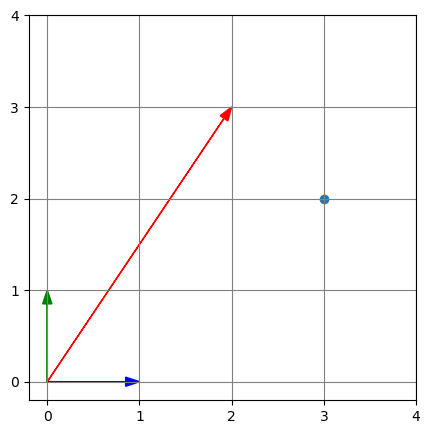

In [103]:
# Пример вектора в matplotlib
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.arrow(0,0, 2,3, head_width=0.1, color='red', length_includes_head=True)
ax.arrow(0,0, 1,0, head_width=0.1, color='blue', length_includes_head=True)
ax.arrow(0,0, 0,1, head_width=0.1, color='green', length_includes_head=True)
ax.scatter(3,2)
ax.set_xticks([0,1, 2, 3, 4])
ax.set_yticks([0,1, 2, 3, 4])
ax.grid(color='grey')

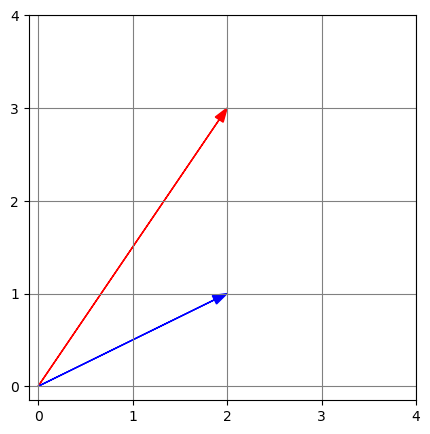

In [108]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.arrow(0,0, 2,3, head_width=0.1, color='red', length_includes_head=True)
ax.arrow(0,0, 2,1, head_width=0.1, color='blue', length_includes_head=True)
ax.set_xticks([0,1, 2, 3, 4])
ax.set_yticks([0,1, 2, 3, 4])
ax.grid(color='grey')

In [109]:
v1 = Matrix([2, 1]); v1
v2 = Matrix([[2,3]]); v2
v2 * v1

Matrix([[7]])

#### Детерминант(определитель) матрицы

In [110]:
M1 = Matrix([[1, 1, 2], [2, 3, 2], [0, 4, 1]])
M1  

Matrix([
[1, 1, 2],
[2, 3, 2],
[0, 4, 1]])

In [111]:
# Разложение по первой строке
1 * M1.minor(0, 0) +(-1) * M1.minor(0, 1) + 2 * M1.minor(0, 2) 

9

In [114]:
# Разложение по второй строке
-2 * M1.minor(1, 0) + 3 * M1.minor(1, 1) + (-2) * M1.minor(1, 2) 

9

In [115]:
# Посчитать детерминант(определитель)
M1.det()

9

In [116]:
# Минор элемента с индексом(0, 0)
M1.minor(0, 0)

-5

In [117]:
# Минор элемента с индексом(0, 1)
M1.minor(0, 1)

2

In [118]:
# Минор элемента с индексом(0, 2)
M1.minor(0, 2)

8

In [119]:
# numpy.linalg as npl
# Обязательно поменять тип данных
npl.det(np.matrix(M1).astype(np.float64))

np.float64(8.999999999999998)

In [120]:
M2 = Matrix([[1, 1, 2], [2, 3, 2], [3, 3, 6]])
M2 

Matrix([
[1, 1, 2],
[2, 3, 2],
[3, 3, 6]])

In [121]:
M2.det()

0

In [122]:
# 3 строка = 2 * 1 строка + 3 * 2 строка
M4 = Matrix([[1, 1, 2], [2, 3, 2], [2 + 6, 2 + 9, 4 + 6]])
M4

Matrix([
[1,  1,  2],
[2,  3,  2],
[8, 11, 10]])

In [123]:
M4.det()

0

In [124]:
M4.rank()

2

In [ ]:
M2 = Matrix([[1, 1, 2], [2, 3, 2], [0, 1, 2]])
M2.det()

4

In [86]:
M2.rank()

3

In [126]:
M3 = M2.copy()
M3

Matrix([
[1, 1, 2],
[2, 3, 2],
[0, 1, 2]])

In [127]:
M3[1, :] = M3[0,:] * 2 + M3[1, :]
M3

Matrix([
[1, 1, 2],
[4, 5, 6],
[0, 1, 2]])

In [89]:
M3.det()  # Значение детерминанта не изменилось

4